# EDA รอบแรก — Polymarket wash trading (บทบาท C)

**เป้าหมาย:** สำรวจตารางเทรดสองสัปดาห์ (1–7 ธ.ค. 2024 = ช่วงพีค, 1–7 มิ.ย. 2025 = ช่วงเงียบ)
เพื่อ (1) ทำสไลด์ Exploration และ (2) **หาปัญหาข้อมูลส่งกลับไปให้ A และ B** ภายใน 4 ต.ค.

| # | หัวข้อ | สถานะ |
|---|---|---|
| 1 | ตารางภาพรวม | ✅ ทำให้แล้ว (ใช้เป็นตัวอย่าง) |
| 2 | volume รายวัน | ✅ ทำให้แล้ว (ใช้เป็นตัวอย่าง) |
| 3 | degree ของกระเป๋า | ✍️ เขียนเอง |
| 4 | หมวดตลาด | ✍️ เขียนเอง |
| 5 | ราคาและขนาดเทรด | ✍️ เขียนเอง |
| 6 | อายุตลาดเทียบหน้าต่างเวลา | ✍️ ครึ่งแรกมีให้แล้ว — **ทำก่อน เพราะ A ต้องใช้ด่วน** |

**ลำดับที่แนะนำ:** 6 → 4 → 3 → 5 · ทุกข้อที่เจอ ให้จดลง `findings.md` ทันที

**รูปแบบที่ใช้ทุกหัวข้อ** (ดูจากหัวข้อ 1–2):
1. คำนวณ aggregate **ใน DuckDB** → ได้ DataFrame เล็ก ๆ (ห้าม `SELECT *` 9 ล้านแถวเข้า pandas)
2. plot สองหน้าต่างข้างกัน ใช้สีประจำหน้าต่าง (ฟ้า = ธ.ค., เขียว = มิ.ย.)
3. `save_fig()` เก็บรูป · `record_stat()` เก็บตัวเลขที่จะอ้างในสไลด์

รัน: เปิดใน VS Code แล้วเลือก kernel จาก `Project/.venv` หรือ
`uv run jupyter nbconvert --to notebook --execute --inplace 03_Analytics/eda/eda_round1.ipynb`

## 0. ตั้งค่า

ดึง path และหน้าต่างเวลาจาก `04_Evaluation/premise_test/config.py` แทนการเขียนซ้ำ
ถ้า A เปลี่ยนหน้าต่างเวลา โน้ตบุ๊กนี้จะตามไปเองในรอบสอง

In [1]:
import json
import sys
from pathlib import Path

import duckdb
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Project/ = two levels up from this notebook (03_Analytics/eda/)
PROJECT = Path.cwd().resolve()
while not (PROJECT / "pyproject.toml").exists():
    PROJECT = PROJECT.parent
sys.path.insert(0, str(PROJECT / "04_Evaluation" / "premise_test"))
from config import INTERIM, RAW, WINDOWS  # noqa: E402

HERE = PROJECT / "03_Analytics" / "eda"
FIG = HERE / "figures"
FIG.mkdir(parents=True, exist_ok=True)

con = duckdb.connect()
# ts is TIMESTAMPTZ. Without this, date_trunc('day', ts) uses the laptop's timezone
# (Asia/Bangkok, +7h) and every "day" would be shifted against the paper's UTC weeks.
con.execute("SET TimeZone = 'UTC'")


def q(sql: str) -> pd.DataFrame:
    # Run SQL in DuckDB and return a (small!) DataFrame
    return con.sql(sql).df()


def trades(w: str) -> str:
    # Path of the clean trade table for one window, ready to paste into FROM '...'
    return str(INTERIM / f"{w}_trades.parquet")


MARKETS = str(RAW / "market_data.parquet")
print("windows:", list(WINDOWS))

windows: ['dec2024', 'jun2025']


In [2]:
# Same hues as plan/make_figures.py and the plan PDF, so "blue = peak week" holds everywhere
C_DATA, C_ALG, C_EVAL, C_EXT = "#0072B2", "#D55E00", "#009E73", "#7B5EA7"
C_INK, C_MUTED = "#1A2733", "#5B6B7A"

WIN = {
    "dec2024": {"label": "Dec 2024 (peak)", "color": C_DATA},
    "jun2025": {"label": "Jun 2025 (quiet)", "color": C_EVAL},
}

plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.edgecolor": C_MUTED, "axes.labelcolor": C_INK, "text.color": C_INK,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 9,
})

STATS: dict = {w: {} for w in WIN}


def save_fig(fig, name: str) -> None:
    # Every figure goes to figures/<name>.png so the slides can pick it up
    fig.tight_layout()
    fig.savefig(FIG / f"{name}.png", bbox_inches="tight")


def record_stat(w: str, key: str, value) -> None:
    # Every number we may quote in the slides goes through here -> eda_stats.json
    value = value.item() if hasattr(value, "item") else value
    # counts come back as floats when pandas mixes column types in one row
    if isinstance(value, float) and value.is_integer():
        value = int(value)
    STATS[w][key] = value

## 1. ภาพรวม: ข้อมูลใหญ่แค่ไหน

**คำถาม:** สัปดาห์เป้าหมายแต่ละช่วงมีกี่เทรด กี่กระเป๋า กี่ตลาด volume เท่าไร
→ ตอบสไลด์ "Complex Data" (big volume + graph) และใช้เป็นตัวตรวจว่าข้อมูลถูก

**ตรวจความถูกต้อง:** จำนวนเทรด / ตลาด / volume ต้องตรงกับ
`04_Evaluation/premise_test/results/extract_stats.json` (1,635,178 / 2,307 / 692.9 M สำหรับ ธ.ค.)

**กระเป๋าต้องนับทั้งสองฝั่ง** — กระเป๋าที่เป็น taker อย่างเดียวจะหายไปถ้านับแค่ `maker`

In [3]:
rows = []
for w in WIN:
    t = trades(w)
    r = q(f'''
        SELECT
            count(*)                         AS trades,
            (SELECT count(*) FROM (
                SELECT maker FROM '{t}' WHERE in_target
                UNION                                  -- UNION removes duplicates
                SELECT taker FROM '{t}' WHERE in_target)) AS wallets,
            count(DISTINCT market)           AS markets,
            sum(shares) / 1e6                AS share_volume_M,
            sum(usdc) / 1e6                  AS usdc_volume_M,
            median(shares)                   AS median_trade_shares
        FROM '{t}'
        WHERE in_target
    ''').iloc[0]
    for k, v in r.items():
        record_stat(w, k, v)
    rows.append(r.rename(WIN[w]["label"]))

overview = pd.DataFrame(rows)
overview["usdc_per_share"] = overview["usdc_volume_M"] / overview["share_volume_M"]
for w, lab in zip(WIN, overview.index):
    record_stat(w, "usdc_per_share", overview.loc[lab, "usdc_per_share"])
overview.round(2)

,trades,wallets,markets,share_volume_M,usdc_volume_M,median_trade_shares,usdc_per_share
Dec 2024 (peak),1635178.0,104186.0,2307.0,692.88,182.68,46.00,0.26
Jun 2025 (quiet),1147205.0,87130.0,3918.0,389.84,169.30,36.91,0.43


In [4]:
# Sanity check against what person A's pipeline reported
ext = {s["window"]: s for s in json.loads(
    (PROJECT / "04_Evaluation/premise_test/results/extract_stats.json").read_text())}
for w in WIN:
    assert STATS[w]["trades"] == ext[w]["target_trades"], w
    assert STATS[w]["markets"] == ext[w]["target_markets"], w
    assert abs(STATS[w]["share_volume_M"] * 1e6 - ext[w]["target_share_volume"]) < 1, w
print("overview matches extract_stats.json ✓")

overview matches extract_stats.json ✓


**อ่านผล:**
- USDC ต่อหุ้นเฉลี่ยแค่ ~0.26 (ธ.ค.) — เทรดส่วนใหญ่อยู่ที่ราคาต่ำ คือตลาด "โอกาสน้อย" ซึ่งเปเปอร์บอกว่า wash ชอบ
  เพราะเทรดวนได้ด้วยเงินน้อย → ตามต่อในหัวข้อ 5
- ธ.ค. มีตลาดน้อยกว่า มิ.ย. (2,307 vs 3,918) แต่ volume มากกว่าเกือบเท่าตัว → volume ต่อตลาดสูงผิดปกติในช่วงพีค

## 2. volume รายวัน: ช่วงพีคกับช่วงเงียบต่างกันแค่ไหน

**คำถาม:** volume และจำนวนเทรดรายวันตลอดหน้าต่าง (lead-in 1 เดือน + สัปดาห์เป้าหมาย) หน้าตาเป็นอย่างไร
มีวันไหนกระโดดผิดปกติไหม (เช่นช่วงเลือกตั้งสหรัฐ 5–6 พ.ย. 2024)

พื้นที่แรเงา = สัปดาห์เป้าหมายที่อัลกอริทึมรายงานผล

dec2024: busiest day 2024-11-06 = 531.7 M shares
jun2025: busiest day 2025-06-03 = 134.6 M shares


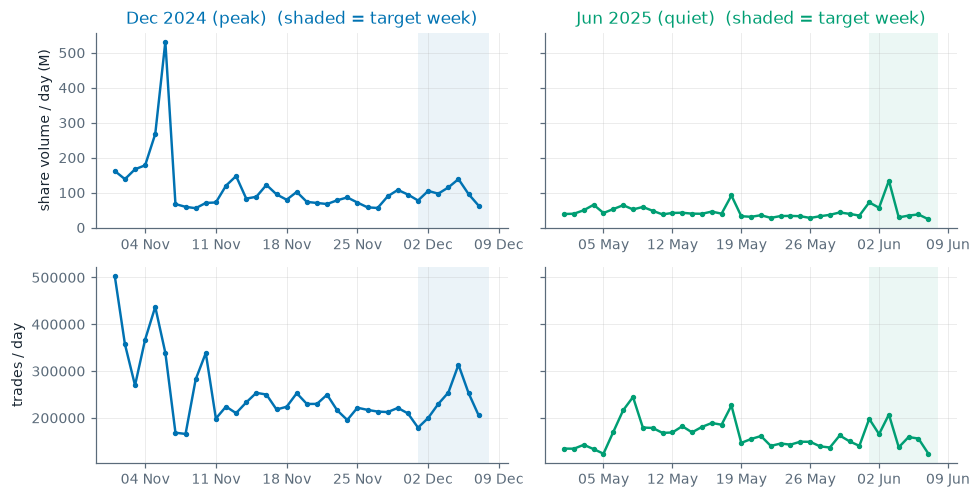

In [5]:
daily = {}
for w in WIN:
    daily[w] = q(f'''
        SELECT date_trunc('day', ts) AS day,
               count(*)              AS trades,
               sum(shares) / 1e6     AS share_volume_M,
               bool_or(in_target)    AS in_target
        FROM '{trades(w)}'
        GROUP BY 1
        ORDER BY 1
    ''')

fig, axes = plt.subplots(2, 2, figsize=(9, 4.6), sharey="row")
for col, w in enumerate(WIN):
    d, c = daily[w], WIN[w]["color"]
    t0 = d.loc[d["in_target"], "day"].min()
    for row, (y, ylab) in enumerate([("share_volume_M", "share volume / day (M)"),
                                     ("trades", "trades / day")]):
        ax = axes[row, col]
        ax.plot(d["day"], d[y], color=c, lw=1.6, marker="o", ms=2.5)
        ax.axvspan(t0, d["day"].max() + pd.Timedelta(days=1), color=c, alpha=0.08, lw=0)
        if col == 0:
            ax.set_ylabel(ylab)
        ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
    axes[0, col].set_title(WIN[w]["label"] + "  (shaded = target week)", color=c)
save_fig(fig, "02_daily_volume")

for w in WIN:
    d = daily[w]
    tgt, lead = d[d["in_target"]], d[~d["in_target"]]
    record_stat(w, "daily_volume_M_target_mean", tgt["share_volume_M"].mean())
    record_stat(w, "daily_volume_M_leadin_mean", lead["share_volume_M"].mean())
    top = d.nlargest(1, "share_volume_M").iloc[0]
    print(f"{w}: busiest day {top['day']:%Y-%m-%d} = {top['share_volume_M']:.1f} M shares")

**อ่านผล:**
- **6 พ.ย. 2024 (UTC) = คืนประกาศผลเลือกตั้งสหรัฐ** (เลือกตั้ง 5 พ.ย. ตามเวลาสหรัฐ) volume 532 M หุ้นในวันเดียว (~5 เท่าของวันปกติ)
  → lead-in ของหน้าต่าง ธ.ค. มีเหตุการณ์ใหญ่ซ้อนอยู่ ตลาดการเมืองที่เปิดก่อน lead-in จะได้ position ผิดเพี้ยนมากที่สุด
  (เชื่อมกับหัวข้อ 6 และกรณีตลาด Trump)
- ธ.ค.: สัปดาห์เป้าหมายเฉลี่ย ~99 M/วัน ต่ำกว่า lead-in (~116 M/วัน) เพราะ lead-in ถูกดึงขึ้นด้วยวันเลือกตั้ง
  ถ้าตัดช่วงเลือกตั้งออก ระดับใกล้กัน → สัปดาห์ที่เลือก **ไม่ใช่** สัปดาห์ผิดปกติ
- มิ.ย.: สัปดาห์เป้าหมาย (~56 M/วัน) สูงกว่า lead-in (~43 M/วัน) เล็กน้อย มี spike 2 มิ.ย. ~135 M → ควรดูว่าเป็นตลาดไหน (รอบสอง)
- ช่วงพีคมี volume ต่อวันราว **2 เท่า** ของช่วงเงียบ ทั้งที่จำนวนเทรดต่างกันน้อยกว่านั้น → เทรดช่วงพีคใหญ่กว่า

## 3. ✍️ degree ของกระเป๋า: เทรดกับคนหลากหลาย หรือกับคู่เดิม

**คำถาม:**
- (3a) กระเป๋าแต่ละใบเทรดกับคู่ที่ไม่ซ้ำกันกี่ใบ (degree) — การกระจายเป็นหางยาวไหม
- (3b) สัดส่วน volume ของกระเป๋าที่เทรดกับ **คู่อันดับ 1** ของตัวเอง — ใกล้ 1 แปลว่าเทรดกับคนเดียวเกือบทั้งหมด (สัญญาณ wash)

**คอลัมน์:** `maker`, `taker`, `shares` · ใช้เฉพาะ `in_target`

**กับดัก:**
- ต้องนับ **ทั้งสองฝั่ง** — แตกแต่ละเทรดเป็นสองแถว (maker→taker และ taker→maker) ก่อน group
  ไม่งั้นกระเป๋าที่เป็น taker บ่อยจะ degree ต่ำผิดจริง
- กราฟ degree ใช้ **CCDF แบบ log–log** (`P(degree ≥ k)`) ไม่ใช่ histogram ธรรมดา — หางยาวจะอ่านไม่ออก
- (3b) ควร **ถ่วงด้วย volume** ของกระเป๋า: กระเป๋าเล็กที่เทรดครั้งเดียวมีค่า = 1 เสมอแต่ไม่สำคัญ

**ควรได้:** กราฟ CCDF สองเส้น (ธ.ค./มิ.ย.) + histogram ของ top-partner share ถ่วง volume
+ ตัวเลข "% volume ที่มาจากกระเป๋าที่ top-partner share ≥ 0.8"

**ส่งถึง:** B — บอกว่าเมทริกซ์ $B$ มีโครงสร้างแบบไหน

In [6]:
# TODO (3a) — fill in the blanks marked /* ... */, then uncomment the lines at the bottom
SQL_EDGES = '''
    -- one row per (wallet, partner) with the volume between them, both directions
    SELECT wallet, partner, sum(shares) AS v
    FROM (
        SELECT maker AS wallet, taker AS partner, shares FROM '{t}' WHERE in_target
        UNION ALL
        SELECT /* ... the other direction ... */ FROM '{t}' WHERE in_target
    )
    GROUP BY 1, 2
'''

SQL_DEGREE = '''
    SELECT wallet,
           count(*)   AS degree,          -- number of distinct partners
           sum(v)     AS vol,
           /* ... */  AS top_partner_share -- hint: max(v) / sum(v)
    FROM ({edges})
    GROUP BY 1
'''

# deg = {w: q(SQL_DEGREE.format(edges=SQL_EDGES.format(t=trades(w)))) for w in WIN}
# CCDF: for k = sorted degrees, P(degree >= k). np.sort + np.arange is enough:
#   x = np.sort(d["degree"]); y = 1 - np.arange(len(x)) / len(x); ax.loglog(x, y)

In [7]:
# TODO (3a) plot CCDF of degree, both windows on one log-log axis -> save_fig(fig, "03a_degree_ccdf")
# TODO (3b) histogram of top_partner_share with weights=vol -> save_fig(fig, "03b_top_partner_share")
# TODO record_stat(w, "vol_share_top_partner_ge_0.8", ...)

**อ่านผล (เติมเอง):**

## 4. ✍️ หมวดตลาด: volume กระจุกที่ไหน

**คำถาม:** volume ของสัปดาห์เป้าหมายแบ่งเป็นหมวด Sports / Politics / Crypto / Other อย่างละกี่ %
เทียบสองช่วง · เปเปอร์พบว่า Sports มี wash ~45% ของ volume

**ปัญหา:** `market_data` **ไม่มีคอลัมน์หมวด** (ตรวจแล้ว 3 ต.ค.) → ต้องจัดหมวดเองด้วยคีย์เวิร์ดจาก `marketName` / `marketSlug`

**การ join:** `market_data.condition = trades.market` — แต่ `market_data` มี **หลายแถวต่อ condition**
(หนึ่งแถวต่อ token) ต้อง `GROUP BY condition` ก่อน join ไม่งั้น volume ซ้ำ 2 เท่า

**กับดัก:**
- ลำดับใน `CASE WHEN` สำคัญ — แถวแรกที่ match ชนะ (เช่น "Will Trump say Bitcoin…" จะไปหมวดไหน?)
- ใช้ `lower(...)` และ regex แบบมีขอบคำ `\b` ไม่งั้น "nba" จะ match กลางคำอื่น
- **ตรวจ Other:** ถ้า Other > ~30% ให้ดู top-20 ตลาดใน Other ตาม volume แล้วเพิ่มคีย์เวิร์ด

**ควรได้:** stacked bar 100% สองแท่ง (ธ.ค./มิ.ย.) + ตาราง % ต่อหมวด

**ส่งถึง:** สไลด์ Exploration + B (ตลาดกีฬาโอกาสน้อยคือที่ที่ wash อยู่ในผล premise test)

In [8]:
# TODO — extend the keyword lists. These are only starters.
SQL_CATEGORY = r'''
    WITH md AS (
        SELECT condition,
               lower(any_value(marketName) || ' ' || any_value(marketSlug)) AS txt
        FROM '{markets}'
        GROUP BY condition                       -- one row per market, avoids double counting
    )
    SELECT condition AS market,
           CASE
             WHEN regexp_matches(txt, '\b(nba|nfl|nhl|mlb|super bowl|stanley cup|premier league|champions league|f1)\b') THEN 'Sports'
             WHEN regexp_matches(txt, '\b(trump|election|president|senate|governor)\b')                               THEN 'Politics'
             WHEN regexp_matches(txt, '\b(bitcoin|btc|eth|ethereum|solana|crypto)\b')                                 THEN 'Crypto'
             ELSE 'Other'
           END AS category
    FROM md
'''

# cat = q(f'''
#     SELECT c.category, sum(t.shares) / 1e6 AS share_volume_M
#     FROM '{trades("dec2024")}' t
#     JOIN ({SQL_CATEGORY.format(markets=MARKETS)}) c USING (market)
#     WHERE t.in_target
#     GROUP BY 1 ORDER BY 2 DESC
# ''')
# TODO: do it for both windows, convert to %, check the % column sums to 100

In [9]:
# TODO: look at the biggest 'Other' markets and add keywords until Other is small
# TODO: stacked 100% bar, both windows -> save_fig(fig, "04_category_share")
# TODO: record_stat(w, "pct_volume_sports", ...) etc.

**อ่านผล (เติมเอง):**

## 5. ✍️ ราคาและขนาดเทรด

**คำถาม:**
- (5a) การกระจายของราคา `usdc / shares` ถ่วงด้วย volume — volume กี่ % อยู่ที่ราคา < 0.05 หรือ > 0.95 (ตลาดโอกาสน้อย/แทบแน่นอน)
- (5b) ขนาดเทรด (`shares`) — มีขนาดไหนเกิดซ้ำผิดปกติไหม (เช่นบอทที่เทรดทีละ 100 หุ้นเป๊ะ ๆ)

**กับดัก:**
- ราคานี้คือราคาของ **token ที่เทรดจริง** (Yes หรือ No) — ใช้ตอบ "ถูกหรือแพง" ได้เลย
  แต่ถ้าจะแปลเป็น "ความน่าจะเป็นที่ Yes ชนะ" ต้องกลับฝั่ง No เป็น `1 − p` (ต้องรู้ฝั่งจาก `condition.positionIds` — ข้ามได้ในรอบนี้)
- histogram ราคาต้องใส่ `weights=volume` ไม่งั้นเทรดเล็กจำนวนมากจะกลบภาพ
- ขนาดเทรดเป็นหางยาวมาก → histogram บน `log10(shares)`
- อย่าดึงทุกแถวมา plot: ให้ DuckDB ทำ bin ก่อน เช่น `floor(usdc/shares * 100) / 100 AS price_bin`

**ควรได้:** histogram ราคาถ่วง volume สองช่วง · histogram log ขนาดเทรด · ตาราง top-10 ขนาดที่เกิดบ่อยที่สุด

**ส่งถึง:** B — ยืนยันว่าตลาดโอกาสน้อยครอง volume ช่วงพีคจริงไหม

In [10]:
# TODO (5a)
SQL_PRICE_BINS = '''
    SELECT floor(usdc / shares * 100) / 100 AS price_bin,   -- 0.00, 0.01, ..., 0.99
           sum(shares) / 1e6                AS share_volume_M
    FROM '{t}'
    WHERE in_target /* ... guard against shares = 0 ... */
    GROUP BY 1 ORDER BY 1
'''
# TODO (5b) bins of log10(shares), and the top-10 most frequent exact share sizes
# TODO plots -> save_fig(fig, "05a_price"), save_fig(fig, "05b_trade_size")
# TODO record_stat(w, "pct_volume_price_lt_0.05", ...), record_stat(w, "pct_volume_price_gt_0.95", ...)

**อ่านผล (เติมเอง):**

## 6. ✍️ อายุตลาดเทียบหน้าต่างเวลา — **ทำก่อน · A ต้องใช้ด่วน**

**ทำไมสำคัญ:** closure ต้องรู้ position ตั้งแต่ตลาดเปิด แต่เรามีข้อมูลย้อนแค่ lead-in 1 เดือน
ตลาดที่ **เปิดก่อน lead-in** จึงอาจถูกนับ closure ผิด (ดู PDF §7 และกรณีตลาด Trump)

**ครึ่งแรกทำให้แล้ว** (cell ถัดไป) — ผลตอนวางแผน: ธ.ค. **70% ของ volume** อยู่ในตลาดที่เปิดก่อน lead-in
(มิ.ย. 53%) — ใหญ่กว่าที่ทุกคนคิด

**TODO (ครึ่งหลัง):**
- ตาราง top-15 ตลาดตาม volume ที่เปิดก่อน lead-in: ชื่อ · `startDate` · volume · เปิดมานานกี่วันก่อน lead-in
- ตลาด "Will Donald Trump be inaugurated?" อยู่ในรายการนี้ไหม เปิดมานานเท่าไร
- (ถ้ามีเวลา) ถ้ากรองตลาดพวกนี้ออก จะเหลือ volume กี่ % — คือราคาของทางเลือก "กรองตามอายุตลาด" ที่ A ต้องตัดสินใจ

**กับดัก:** `startDate` เป็น **ข้อความ** ISO-8601 — เทียบแบบ string กับ `'2024-11-01'` ได้เพราะรูปแบบเรียงตามเวลา
แต่ถ้าจะคำนวณจำนวนวันต้อง `CAST(startDate AS TIMESTAMPTZ)` ก่อน · บางแถว `startDate` ว่าง

In [11]:
SQL_MARKET_AGE = '''
    WITH m AS (
        SELECT market, sum(shares) AS v
        FROM '{t}' WHERE in_target GROUP BY 1
    ),
    md AS (
        SELECT condition, any_value(marketName) AS name, min(startDate) AS start_date
        FROM '{markets}' GROUP BY 1
    )
    SELECT m.market, md.name, md.start_date, m.v,
           md.start_date < '{lead}' AS opened_before_leadin
    FROM m LEFT JOIN md ON md.condition = m.market
'''

age = {}
for w, cfg in WINDOWS.items():
    age[w] = q(SQL_MARKET_AGE.format(t=trades(w), markets=MARKETS, lead=cfg["lead_start"]))
    a = age[w]
    pct_mk = 100 * a["opened_before_leadin"].mean()
    pct_vol = 100 * a.loc[a["opened_before_leadin"], "v"].sum() / a["v"].sum()
    record_stat(w, "pct_markets_opened_before_leadin", pct_mk)
    record_stat(w, "pct_volume_in_markets_opened_before_leadin", pct_vol)
    record_stat(w, "markets_with_name", int(a["name"].fillna("").ne("").sum()))
    print(f"{w}: {pct_mk:.1f}% of markets / {pct_vol:.1f}% of volume opened before lead-in "
          f"({cfg['lead_start']}) · named markets {STATS[w]['markets_with_name']}/{len(a)}")

dec2024: 42.2% of markets / 69.7% of volume opened before lead-in (2024-11-01) · named markets 2307/2307


jun2025: 35.4% of markets / 52.6% of volume opened before lead-in (2025-05-01) · named markets 3898/3918


In [12]:
# TODO: top-15 markets opened before lead-in, by volume, with days_before_leadin
# hint: age["dec2024"].query("opened_before_leadin").nlargest(15, "v")
#       days = (pd.Timestamp(lead, tz="UTC") - pd.to_datetime(start_date, utc=True)).dt.days
# TODO: is the Trump-inauguration market in the list?

**อ่านผล (เติมเอง):**

## บันทึกตัวเลขทั้งหมด

รัน cell นี้ท้ายสุดเสมอ → `eda_stats.json` คือแหล่งเดียวของตัวเลขที่จะอ้างในสไลด์และรายงาน

In [13]:
(HERE / "eda_stats.json").write_text(json.dumps(STATS, indent=2, default=str))
print(json.dumps(STATS, indent=2, default=str))

{
  "dec2024": {
    "trades": 1635178,
    "wallets": 104186,
    "markets": 2307,
    "share_volume_M": 692.882130919304,
    "usdc_volume_M": 182.68252273802722,
    "median_trade_shares": 46,
    "usdc_per_share": 0.26365598791766676,
    "daily_volume_M_target_mean": 98.98316155990425,
    "daily_volume_M_leadin_mean": 115.53664951882396,
    "pct_markets_opened_before_leadin": 42.17598612917208,
    "pct_volume_in_markets_opened_before_leadin": 69.71440877952907,
    "markets_with_name": 2307
  },
  "jun2025": {
    "trades": 1147205,
    "wallets": 87130,
    "markets": 3918,
    "share_volume_M": 389.84004783126875,
    "usdc_volume_M": 169.30303867179325,
    "median_trade_shares": 36.906,
    "usdc_per_share": 0.4342884719352161,
    "daily_volume_M_target_mean": 55.69143540446628,
    "daily_volume_M_leadin_mean": 43.103322284474864,
    "pct_markets_opened_before_leadin": 35.37519142419602,
    "pct_volume_in_markets_opened_before_leadin": 52.64099326472467,
    "markets_wi